In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import tqdm
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import numpy as np

In [4]:
import pandas as pd
import seaborn as sns
sns.set_context('talk')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde, norm
import tqdm
import textwrap
import warnings
warnings.filterwarnings('ignore')

os.chdir("../../ChopTFs/pipeline/")
import time_normalization_helpers

In [5]:
import pandas as pd
import os
import subprocess
from glob import glob
import duckdb
import os
import tempfile
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# Goal: Use both read depth and pool size to normalize

## 1. Getting unique UMIs

In [8]:
files = glob("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/trebl_experiment_pool_C_umi_/*/*_reads_per_umi.tsv")
files[:3]

['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_AD_3_5/AD_3_5_reads_per_umi.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_AD_2_0/AD_2_0_reads_per_umi.tsv',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/trebl_experiment_pool_C_umi_/trebl_experiment_pool_C_umi_RPTR_2_5_S9_R1_001_fastp/RPTR_2_5_S9_R1_001_fastp_reads_per_umi.tsv']

In [11]:
def parse_metadata(filepath):
    fname = os.path.basename(filepath)

    # Example: AD_2_0_S1_R1_001_fastp_reads_per_umi.tsv
    m = re.match(r"(AD|RPTR)_(\d+)_(\d+)_", fname)
    
    if m is None:
        return None

    construct, val1, val2 = m.groups()

    return {
        "construct": construct,
        "val1": int(val1),
        "val2": int(val2)    }

In [12]:
import subprocess
from joblib import Parallel, delayed
def count_rows_wc(f):
    meta = parse_metadata(f)
    if meta is None:
        return None

    result = subprocess.run(["wc", "-l", f], capture_output=True, text=True)
    n = int(result.stdout.strip().split()[0]) - 1  # subtract header

    return {**meta, "n_rows": n}

results = Parallel(n_jobs=32)(
    delayed(count_rows_wc)(f) for f in tqdm.tqdm(files)
)

counts_df = pd.DataFrame([r for r in results if r is not None])

100%|██████████| 42/42 [00:00<00:00, 104.06it/s]


In [13]:
counts_df

,construct,val1,val2,n_rows
0,AD,3,5,14574667
1,AD,2,0,15712033
2,RPTR,2,5,8570606
3,RPTR,2,10,15410789
4,RPTR,3,240,35529224
5,AD,2,15,16103521
6,RPTR,1,5,8073891
7,AD,1,10,16340269
8,AD,3,30,12304152
9,AD,3,10,15453584


In [14]:
AD_total_umis = counts_df[counts_df["construct"] == "AD"]
AD_total_umis = AD_total_umis.drop(columns = 'construct')
AD_total_umis.columns = ["rep", "time", "AD_total_umis"]
AD_total_umis.head(3)

,rep,time,AD_total_umis
0,3,5,14574667
1,2,0,15712033
5,2,15,16103521


In [15]:
RT_total_umis = counts_df[counts_df["construct"] == "RPTR"]
RT_total_umis = RT_total_umis.drop(columns = 'construct')
RT_total_umis.columns = ["rep", "time", "RT_total_umis"]
RT_total_umis.head(3)

,rep,time,RT_total_umis
2,2,5,8570606
3,2,10,15410789
4,3,240,35529224


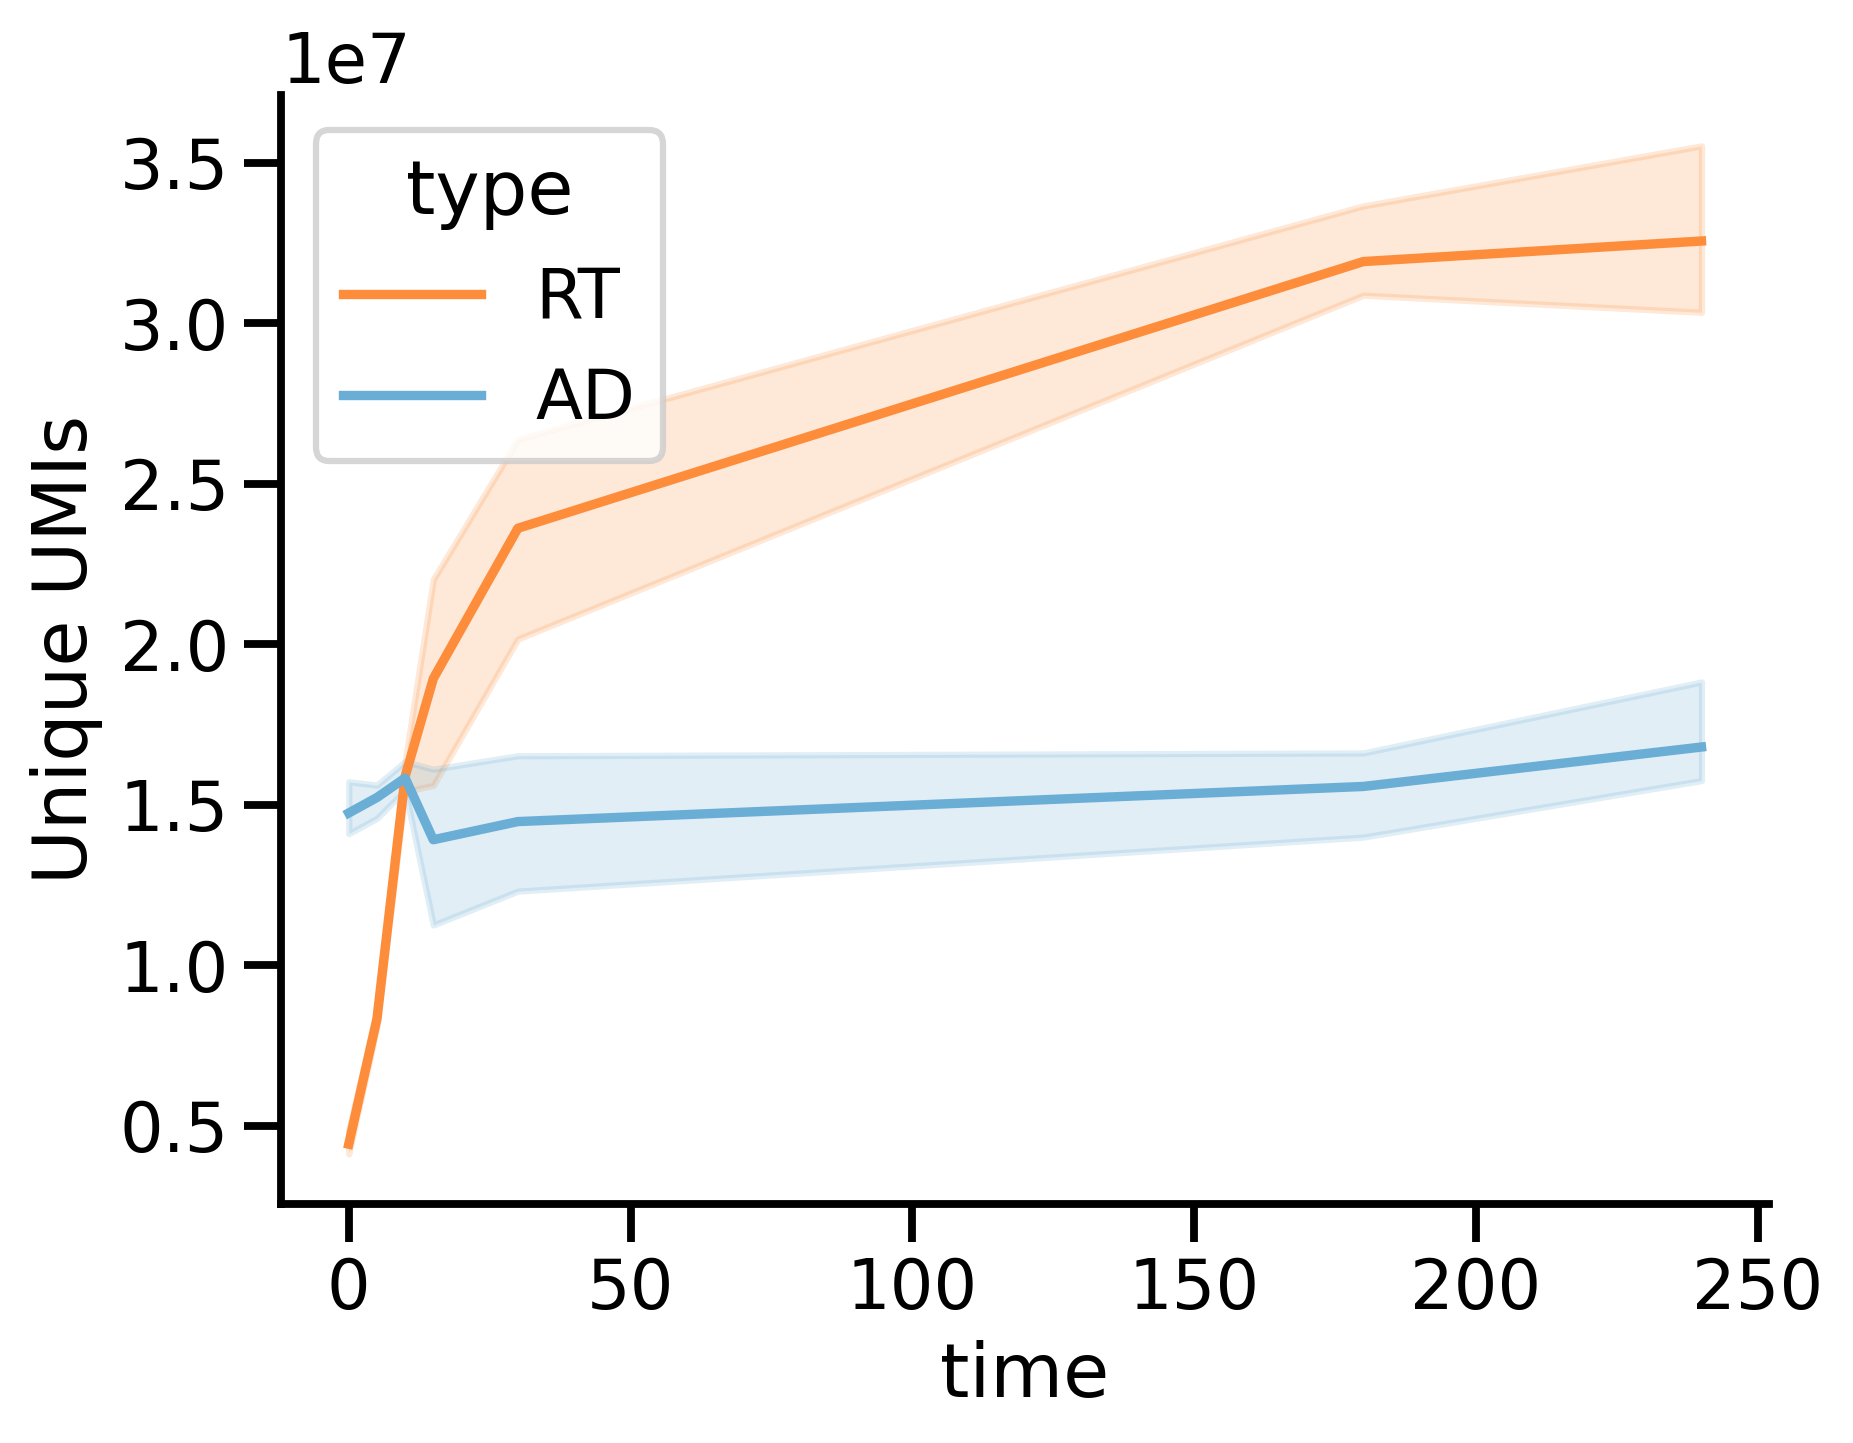

In [16]:
plt.figure(dpi = 300)
RT_total_umis = RT_total_umis.rename(columns={"RT_total_umis": "umis"})
AD_total_umis = AD_total_umis.rename(columns={"AD_total_umis": "umis"})

RT_total_umis["type"] = "RT"
AD_total_umis["type"] = "AD"

df = pd.concat([RT_total_umis, AD_total_umis], ignore_index=True)

sns.lineplot(
    data=df,
    x="time",
    y="umis",
    hue="type",              # AD vs RT → color
    palette={
        "AD": sns.color_palette("Blues", 3)[1],
        "RT": sns.color_palette("Oranges", 3)[1],
    }
)

plt.ylabel("Unique UMIs")
sns.despine()

## 2. Estimating pool size

### AD

In [19]:
RT_df = pd.read_csv("../../../output/GCN4_preseq_RT.csv")
RT_df

,Unnamed: 0,pop_size_estimate,lower_ci,upper_ci,converged,rep,time
0,0,1.411479e+08,65567933.4,2.068118e+09,not_converged,1,0
1,6,1.882170e+08,132109995.7,6.473644e+08,not_converged,1,5
2,1,4.103997e+08,318340893.3,2.067977e+09,not_converged,1,10
3,2,3.611551e+08,294169353.8,6.850845e+08,not_converged,1,15
4,5,5.550410e+08,454734221.6,3.100442e+09,not_converged,1,30
5,3,1.074258e+09,513544449.5,7.337379e+09,not_converged,1,180
6,4,6.716922e+08,562754806.9,3.249165e+09,not_converged,1,240
7,7,1.861713e+08,69585119.9,4.096803e+09,not_converged,2,0
8,13,2.301726e+08,148158080.0,1.864528e+09,not_converged,2,5
9,8,5.217352e+08,291521856.6,3.461668e+09,not_converged,2,10


In [20]:
RT_df = pd.read_csv("../../../output/GCN4_preseq_RT.csv")
RT_df

,Unnamed: 0,pop_size_estimate,lower_ci,upper_ci,converged,rep,time
0,0,1.411479e+08,65567933.4,2.068118e+09,not_converged,1,0
1,6,1.882170e+08,132109995.7,6.473644e+08,not_converged,1,5
2,1,4.103997e+08,318340893.3,2.067977e+09,not_converged,1,10
3,2,3.611551e+08,294169353.8,6.850845e+08,not_converged,1,15
4,5,5.550410e+08,454734221.6,3.100442e+09,not_converged,1,30
5,3,1.074258e+09,513544449.5,7.337379e+09,not_converged,1,180
6,4,6.716922e+08,562754806.9,3.249165e+09,not_converged,1,240
7,7,1.861713e+08,69585119.9,4.096803e+09,not_converged,2,0
8,13,2.301726e+08,148158080.0,1.864528e+09,not_converged,2,5
9,8,5.217352e+08,291521856.6,3.461668e+09,not_converged,2,10


In [24]:
AD_df = pd.read_csv("../../../output/GCN4_preseq_AD.csv")
AD_df

,Unnamed: 0,pop_size_estimate,lower_ci,upper_ci,rep,time
0,0,13856276.5,10253555.5,15598917.1,1,0
1,1,14458222.2,10768754.2,16345091.7,1,5
2,2,14739967.9,12152555.2,19026489.8,1,10
3,3,11722134.3,9418236.1,13105713.7,1,15
4,4,14041660.8,11365888.7,16909085.5,1,30
5,5,15267786.6,12591072.7,18849104.5,1,180
6,6,16305573.2,13449213.2,17300671.4,1,240
7,7,14239829.4,11463355.3,15725991.2,2,0
8,8,14289007.3,12045175.5,16628934.7,2,5
9,9,13884127.1,12656093.3,16499957.7,2,10


## 3. Normalizing by read depth and pool size

In [25]:
activities_per_bc = pd.read_csv("../../../output/GCN4_pipeline/trebl_experiment_pool_C_umi_results_per_barcode.csv", index_col = 0)
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729
...,...,...,...,...,...,...,...,...,...,...,...
342856,TCTGGTCATCAAGTTGTTAATTCTTCTTCTTTGAATATTCCAAGAG...,GGATATTACAC,TCTTAAAGGTCAGA,1,30,46,43,23,16,-0.693147,-0.988611
342857,ACTAATACTGCTCCAACTACATTTACTTCTGGTTTGTGTTCTTCTT...,GATAAGACTAC,CCCAATCCCCGGCG,1,30,46,46,3,2,-2.730029,-3.135494
342858,GAAGAAGAAACTAAAGCTGCTGAACCAAATTATGGTTCTGTTGCTA...,ATACGAGAGGT,CACGCTTAGGATAT,1,30,46,43,3,3,-2.730029,-2.662588
342859,TCTTCTTCTTCTTCTCCAAATAACTTTGCTCCAATTGACTTTACTT...,TCTCATATAAT,CTTGTAGTGGCGGC,1,30,46,42,36,25,-0.245122,-0.518794


In [26]:
activities_per_bc = pd.merge(activities_per_bc, RT_df[["pop_size_estimate", "rep", "time"]].rename(columns={"pop_size_estimate" : "RT_pool_size"}))
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,RT_pool_size
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,410399668.5
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,410399668.5
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,410399668.5
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,410399668.5
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,410399668.5
...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,361155110.7
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,361155110.7
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,361155110.7
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,361155110.7


In [27]:
activities_per_bc = pd.merge(activities_per_bc, AD_df[["pop_size_estimate", "rep", "time"]].rename(columns={"pop_size_estimate" : "AD_pool_size"}))
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,RT_pool_size,AD_pool_size
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,410399668.5,14739967.9
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,410399668.5,14739967.9
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,410399668.5,14739967.9
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,410399668.5,14739967.9
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,410399668.5,14739967.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,361155110.7,11722134.3
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,361155110.7,11722134.3
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,361155110.7,11722134.3
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,361155110.7,11722134.3


In [29]:
activities_per_bc = pd.merge(activities_per_bc, AD_total_umis.rename(columns={"umis" : "AD_umis"}).drop(columns = 'type'))
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,RT_pool_size,AD_pool_size,AD_umis
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,410399668.5,14739967.9,16340269
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,410399668.5,14739967.9,16340269
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,410399668.5,14739967.9,16340269
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,410399668.5,14739967.9,16340269
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,410399668.5,14739967.9,16340269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,361155110.7,11722134.3,11248280
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,361155110.7,11722134.3,11248280
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,361155110.7,11722134.3,11248280
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,361155110.7,11722134.3,11248280


In [30]:
activities_per_bc = pd.merge(activities_per_bc, RT_total_umis.rename(columns={"umis" : "RT_umis"}).drop(columns = 'type'))
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,RT_pool_size,AD_pool_size,AD_umis,RT_umis
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,410399668.5,14739967.9,16340269,15873462
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,410399668.5,14739967.9,16340269,15873462
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,410399668.5,14739967.9,16340269,15873462
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,410399668.5,14739967.9,16340269,15873462
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,410399668.5,14739967.9,16340269,15873462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,361155110.7,11722134.3,11248280,15595956
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,361155110.7,11722134.3,11248280,15595956
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,361155110.7,11722134.3,11248280,15595956
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,361155110.7,11722134.3,11248280,15595956


In [33]:
activities_per_bc["AD_count_umi_pool_norm"] = (activities_per_bc["count_directional_AD"] * activities_per_bc["AD_pool_size"]) / activities_per_bc["AD_umis"]
activities_per_bc["RT_count_umi_pool_norm"] = (activities_per_bc["count_directional_RT"] * activities_per_bc["RT_pool_size"]) / activities_per_bc["RT_umis"]
activities_per_bc["score_umi_pool_norm"] = np.log(activities_per_bc["RT_count_umi_pool_norm"] / activities_per_bc["AD_count_umi_pool_norm"])
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,RT_pool_size,AD_pool_size,AD_umis,RT_umis,AD_count_umi_pool_norm,RT_count_umi_pool_norm,score_umi_pool_norm
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,-0.653142,410399668.5,14739967.9,16340269,15873462,88.402269,1318.577075,2.702411
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,-3.025291,410399668.5,14739967.9,16340269,15873462,92.912589,129.272262,0.330262
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,-2.555287,410399668.5,14739967.9,16340269,15873462,92.912589,206.835620,0.800265
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,-2.833213,410399668.5,14739967.9,16340269,15873462,92.010525,155.126715,0.522339
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,-2.525729,410399668.5,14739967.9,16340269,15873462,90.206397,206.835620,0.829824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,-0.693147,361155110.7,11722134.3,11248280,15595956,2.084254,23.156972,2.407885
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,4.166665,361155110.7,11722134.3,11248280,15595956,2.084254,2987.249341,7.267697
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,0.693147,361155110.7,11722134.3,11248280,15595956,1.042127,46.313943,3.794179
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,0.693147,361155110.7,11722134.3,11248280,15595956,1.042127,46.313943,3.794179


In [34]:
activities_per_bc["AD_count_norm_umi_only"] = (activities_per_bc["count_directional_AD"] ) / activities_per_bc["AD_umis"]
activities_per_bc["RT_count_norm_umi_only"] = (activities_per_bc["count_directional_RT"] ) / activities_per_bc["RT_umis"]
activities_per_bc["score_umi_only"] = np.log(activities_per_bc["RT_count_norm_umi_only"] / activities_per_bc["AD_count_norm_umi_only"])
activities_per_bc

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,...,RT_pool_size,AD_pool_size,AD_umis,RT_umis,AD_count_umi_pool_norm,RT_count_umi_pool_norm,score_umi_pool_norm,AD_count_norm_umi_only,RT_count_norm_umi_only,score_umi_only
0,GCTGCTGTTGATTTGAACTTTGAAGCTGCTATTCCATCTTCTAGAG...,GCATATAGAGA,CCTGCTATTCGTAA,1,10,106,98,80,51,-0.281412,...,410399668.5,14739967.9,16340269,15873462,88.402269,1318.577075,2.702411,5.997453e-06,3.212910e-06,-0.624158
1,TCTAATACTCAAGCTGTTACTGGTCAACATAGAAGACATTCTTCTA...,CCACAGACGGA,TACCTCCGACTGTC,1,10,106,103,6,5,-2.871680,...,410399668.5,14739967.9,16340269,15873462,92.912589,129.272262,0.330262,6.303446e-06,3.149911e-07,-2.996307
2,GCTGAAATTAGAGGTGGTACTAGATTGGTTTGTAGAAGAGAGAATG...,CAGACCAAGAA,GTGGTCAAGGCTCG,1,10,106,103,12,8,-2.178532,...,410399668.5,14739967.9,16340269,15873462,92.912589,206.835620,0.800265,6.303446e-06,5.039858e-07,-2.526304
3,GAAGTTGGTGACTTCTCTGTTAATAAACCACCACAAGCTGATGATA...,ATTTGTACTAG,CCATGTTTGGCGAA,1,10,106,102,7,6,-2.717529,...,410399668.5,14739967.9,16340269,15873462,92.010525,155.126715,0.522339,6.242247e-06,3.779894e-07,-2.804229
4,TTGGCTTCTCCACATTTGTTGTTGGTTAATGTTCATTGTCATGAAC...,AACGTTCCTCA,ATATAAAGCGATTG,1,10,106,100,10,8,-2.360854,...,410399668.5,14739967.9,16340269,15873462,90.206397,206.835620,0.829824,6.119850e-06,5.039858e-07,-2.496745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342856,TTGGGTCCAACTGTTTCTCCTAAAGATATCTTTAATATTGATTCTG...,CCCCCTCACGC,CCCTGCCCCGTTAG,1,15,2,2,2,1,0.000000,...,361155110.7,11722134.3,11248280,15595956,2.084254,23.156972,2.407885,1.778050e-07,6.411919e-08,-1.019944
342857,TCTGGTTCTACTAGAACTGTTTCTCCTAAAGATATCTTTGCTGATG...,AATTGAGCAAA,TTCTTCGTACCTAA,1,15,2,2,209,129,4.649187,...,361155110.7,11722134.3,11248280,15595956,2.084254,2987.249341,7.267697,1.778050e-07,8.271375e-06,3.839869
342858,CAACAAACTCCATCTGTTGCTAAGATGTCTATTGCTGAATTGGATG...,GAAGAATCTGA,TCTACAGATAAGTT,1,15,1,1,6,2,1.791759,...,361155110.7,11722134.3,11248280,15595956,1.042127,46.313943,3.794179,8.890248e-08,1.282384e-07,0.366351
342859,AGATTTAATTCTATTGCTCAGAATCAATCTCAACATCAACAATTCT...,AGAATCAGTAA,TGAGAGCGAGGCGA,1,15,1,1,3,2,1.098612,...,361155110.7,11722134.3,11248280,15595956,1.042127,46.313943,3.794179,8.890248e-08,1.282384e-07,0.366351


## 3. Distribution of normalized activity over time?

100%|██████████| 7/7 [00:00<00:00, 54.52it/s]


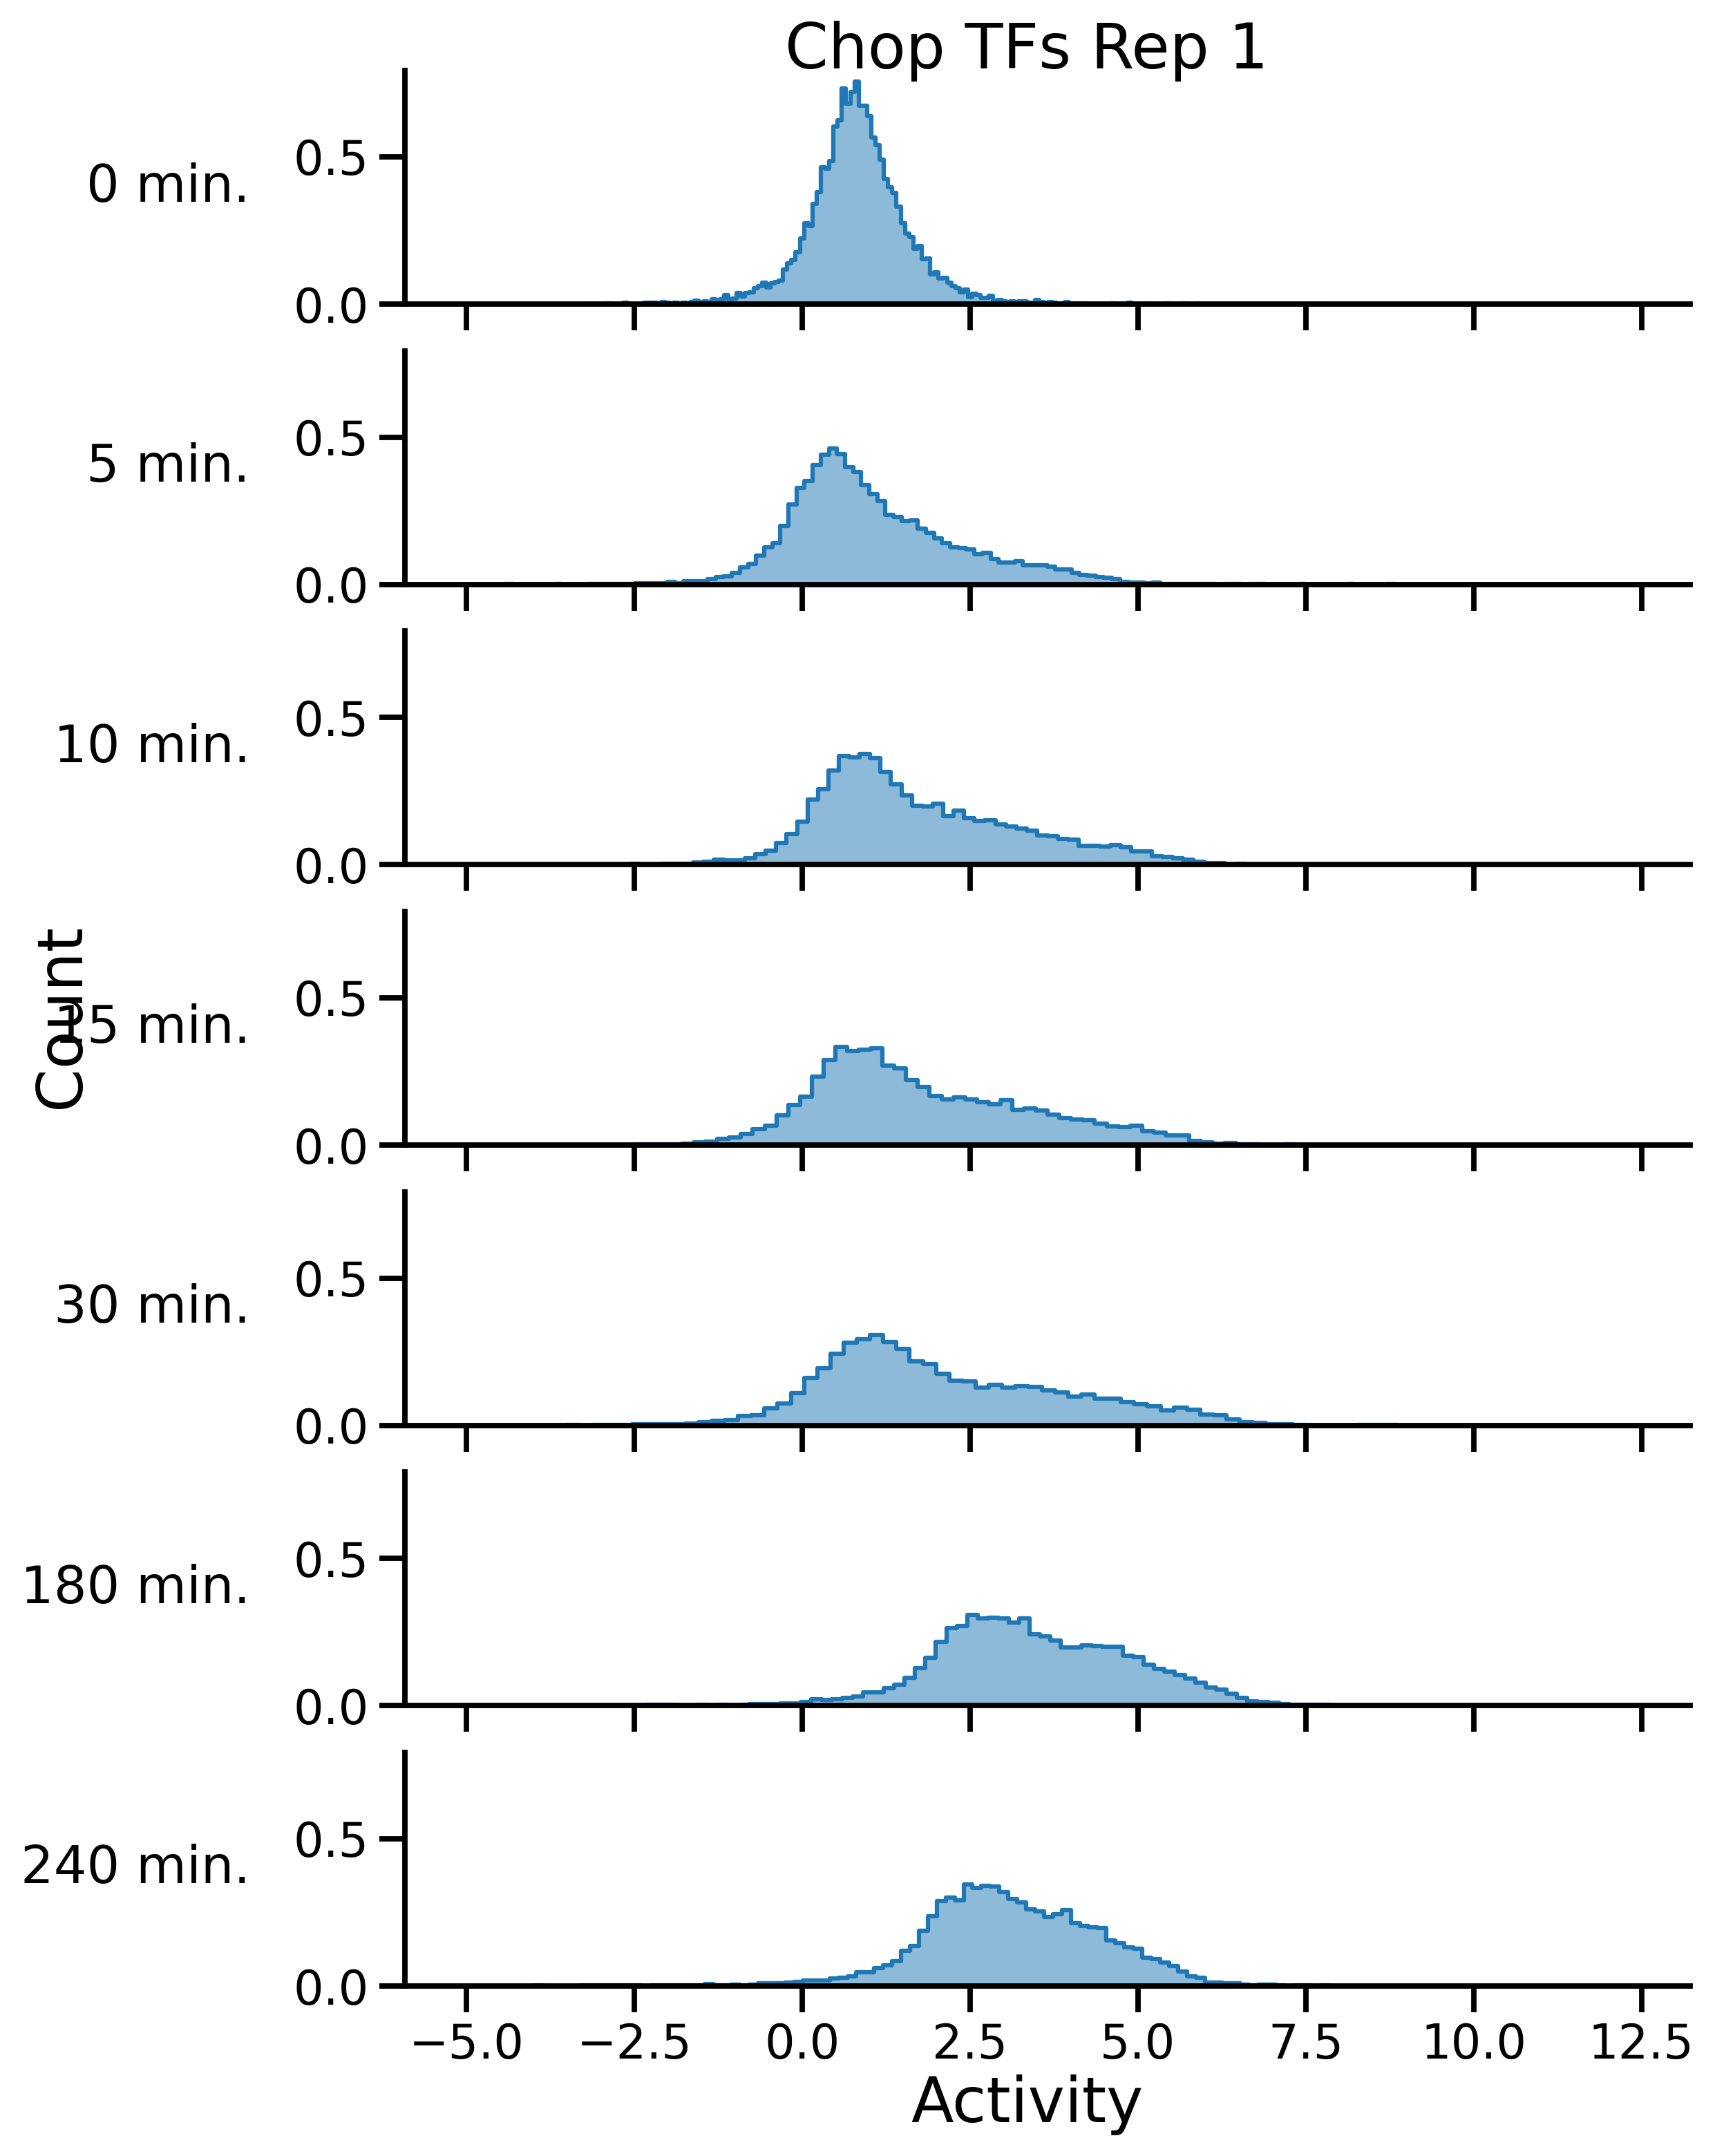

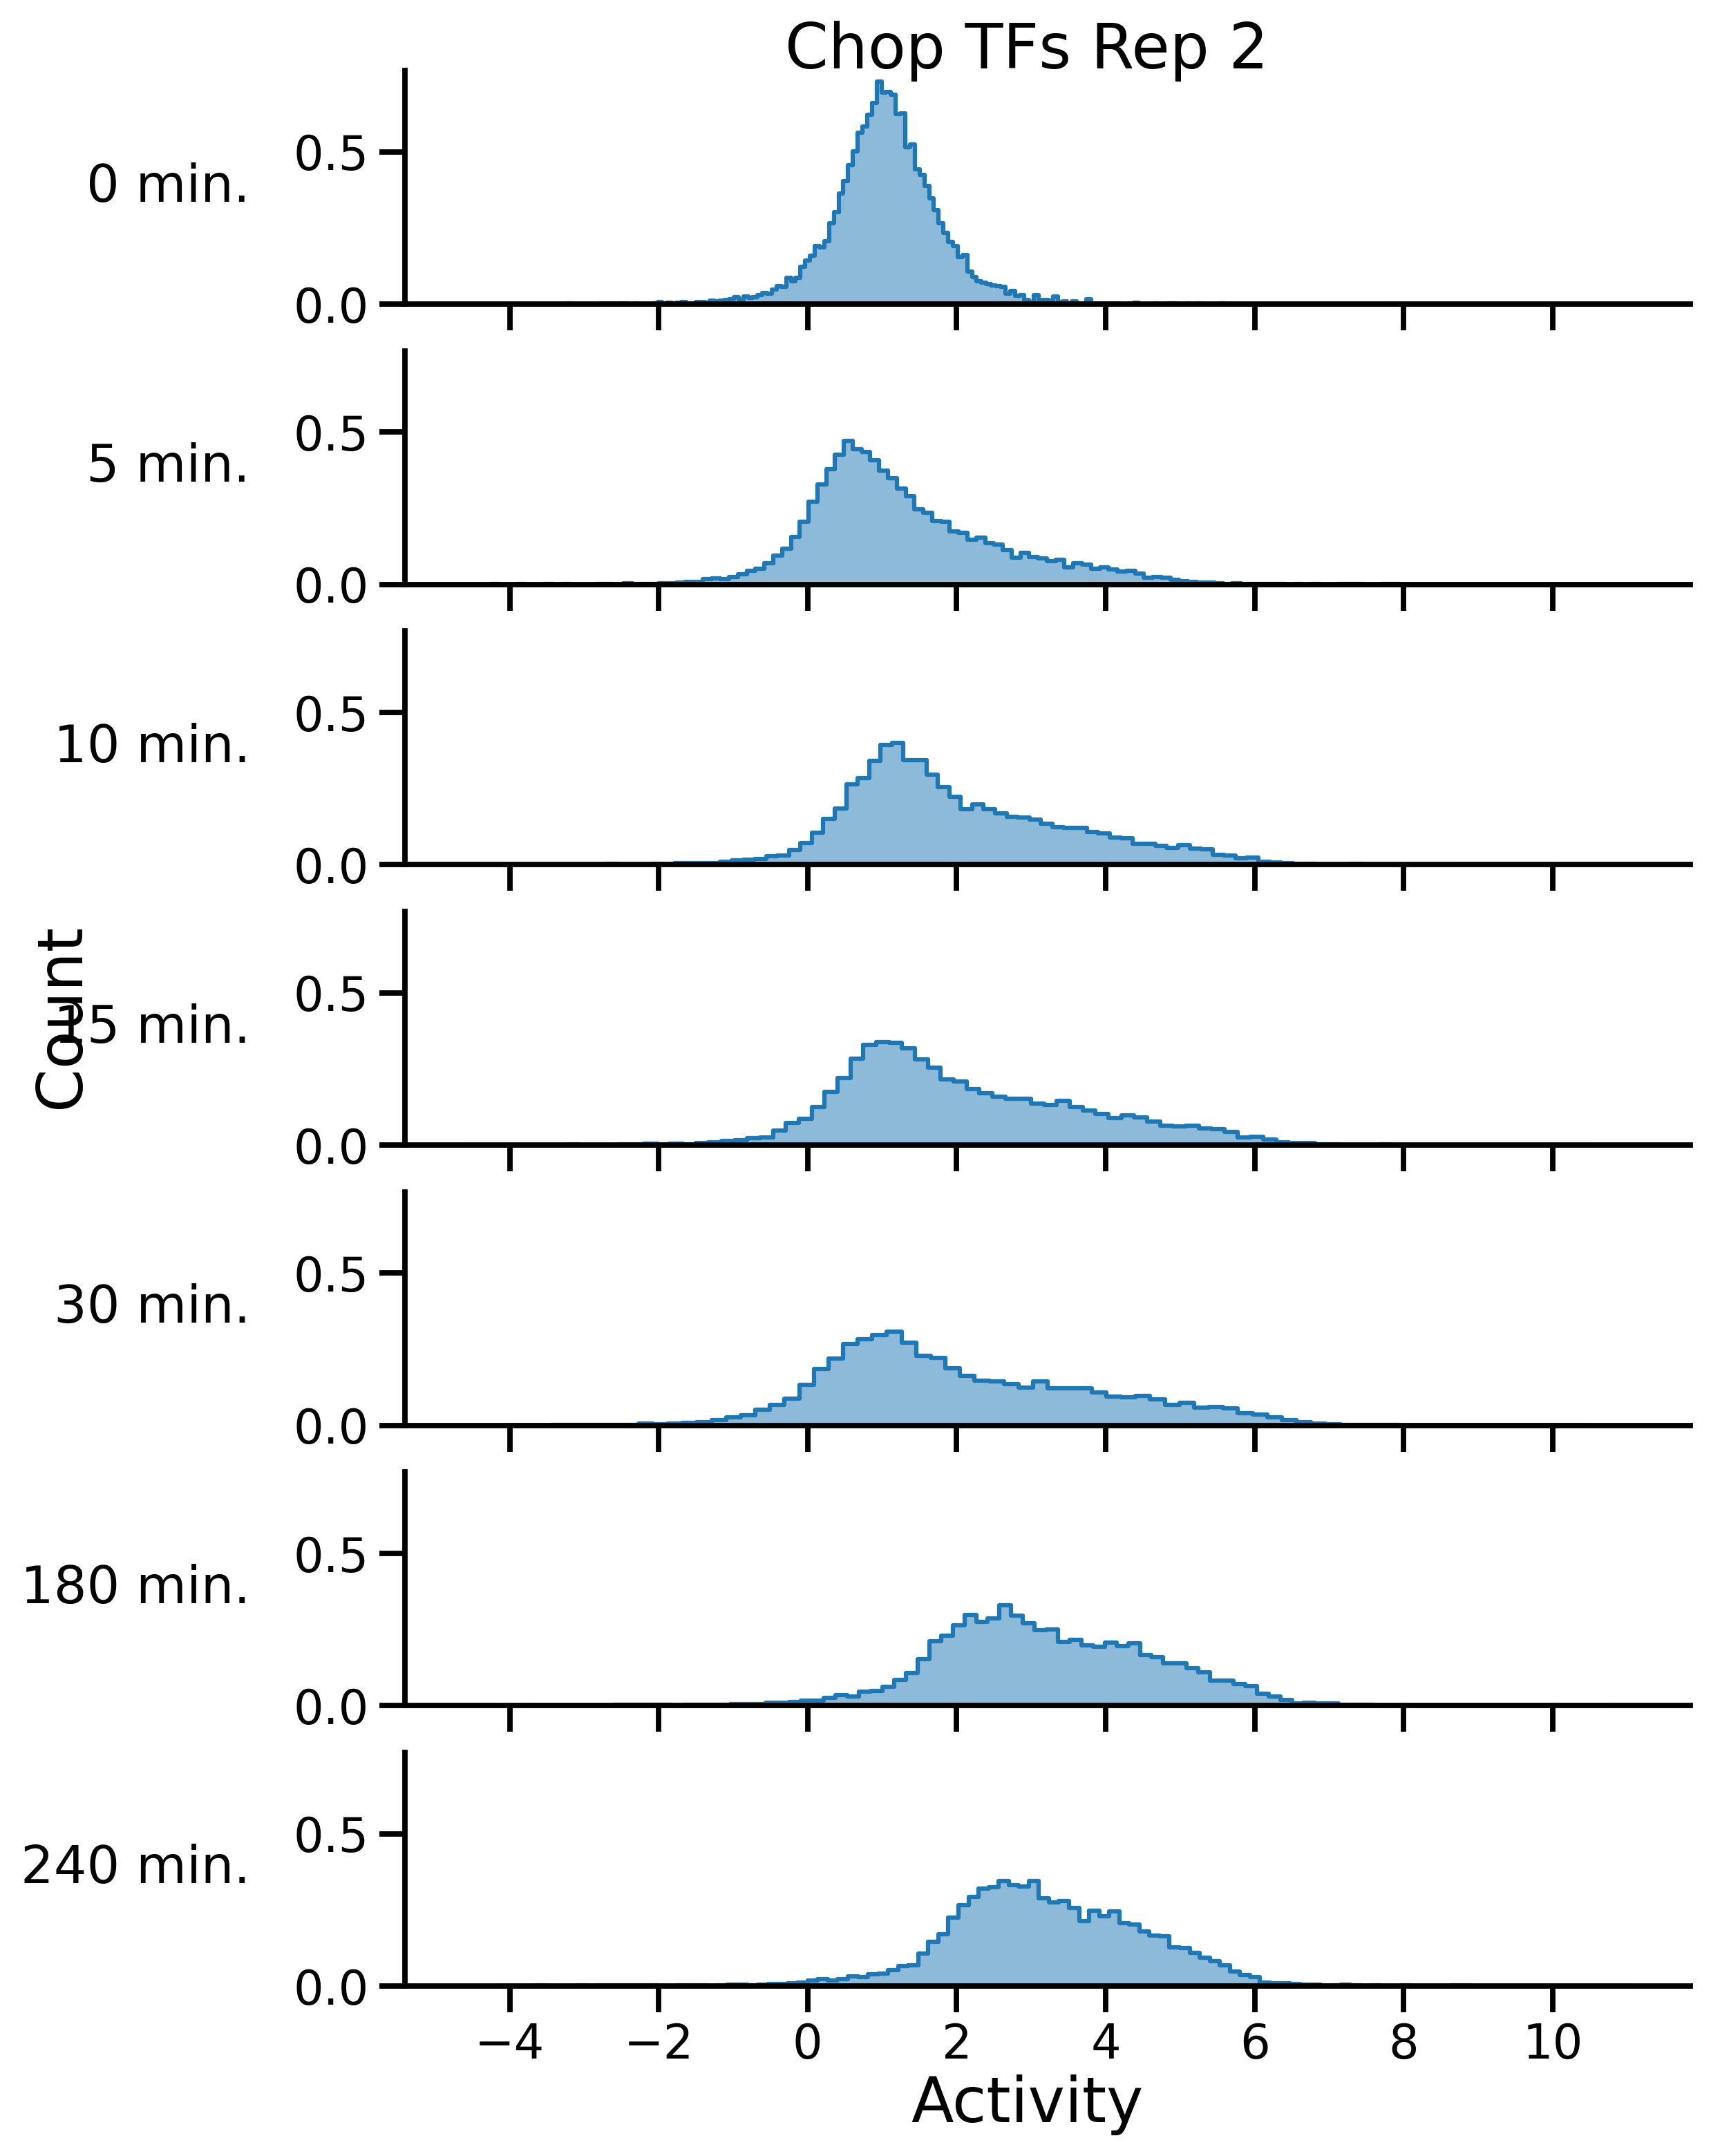

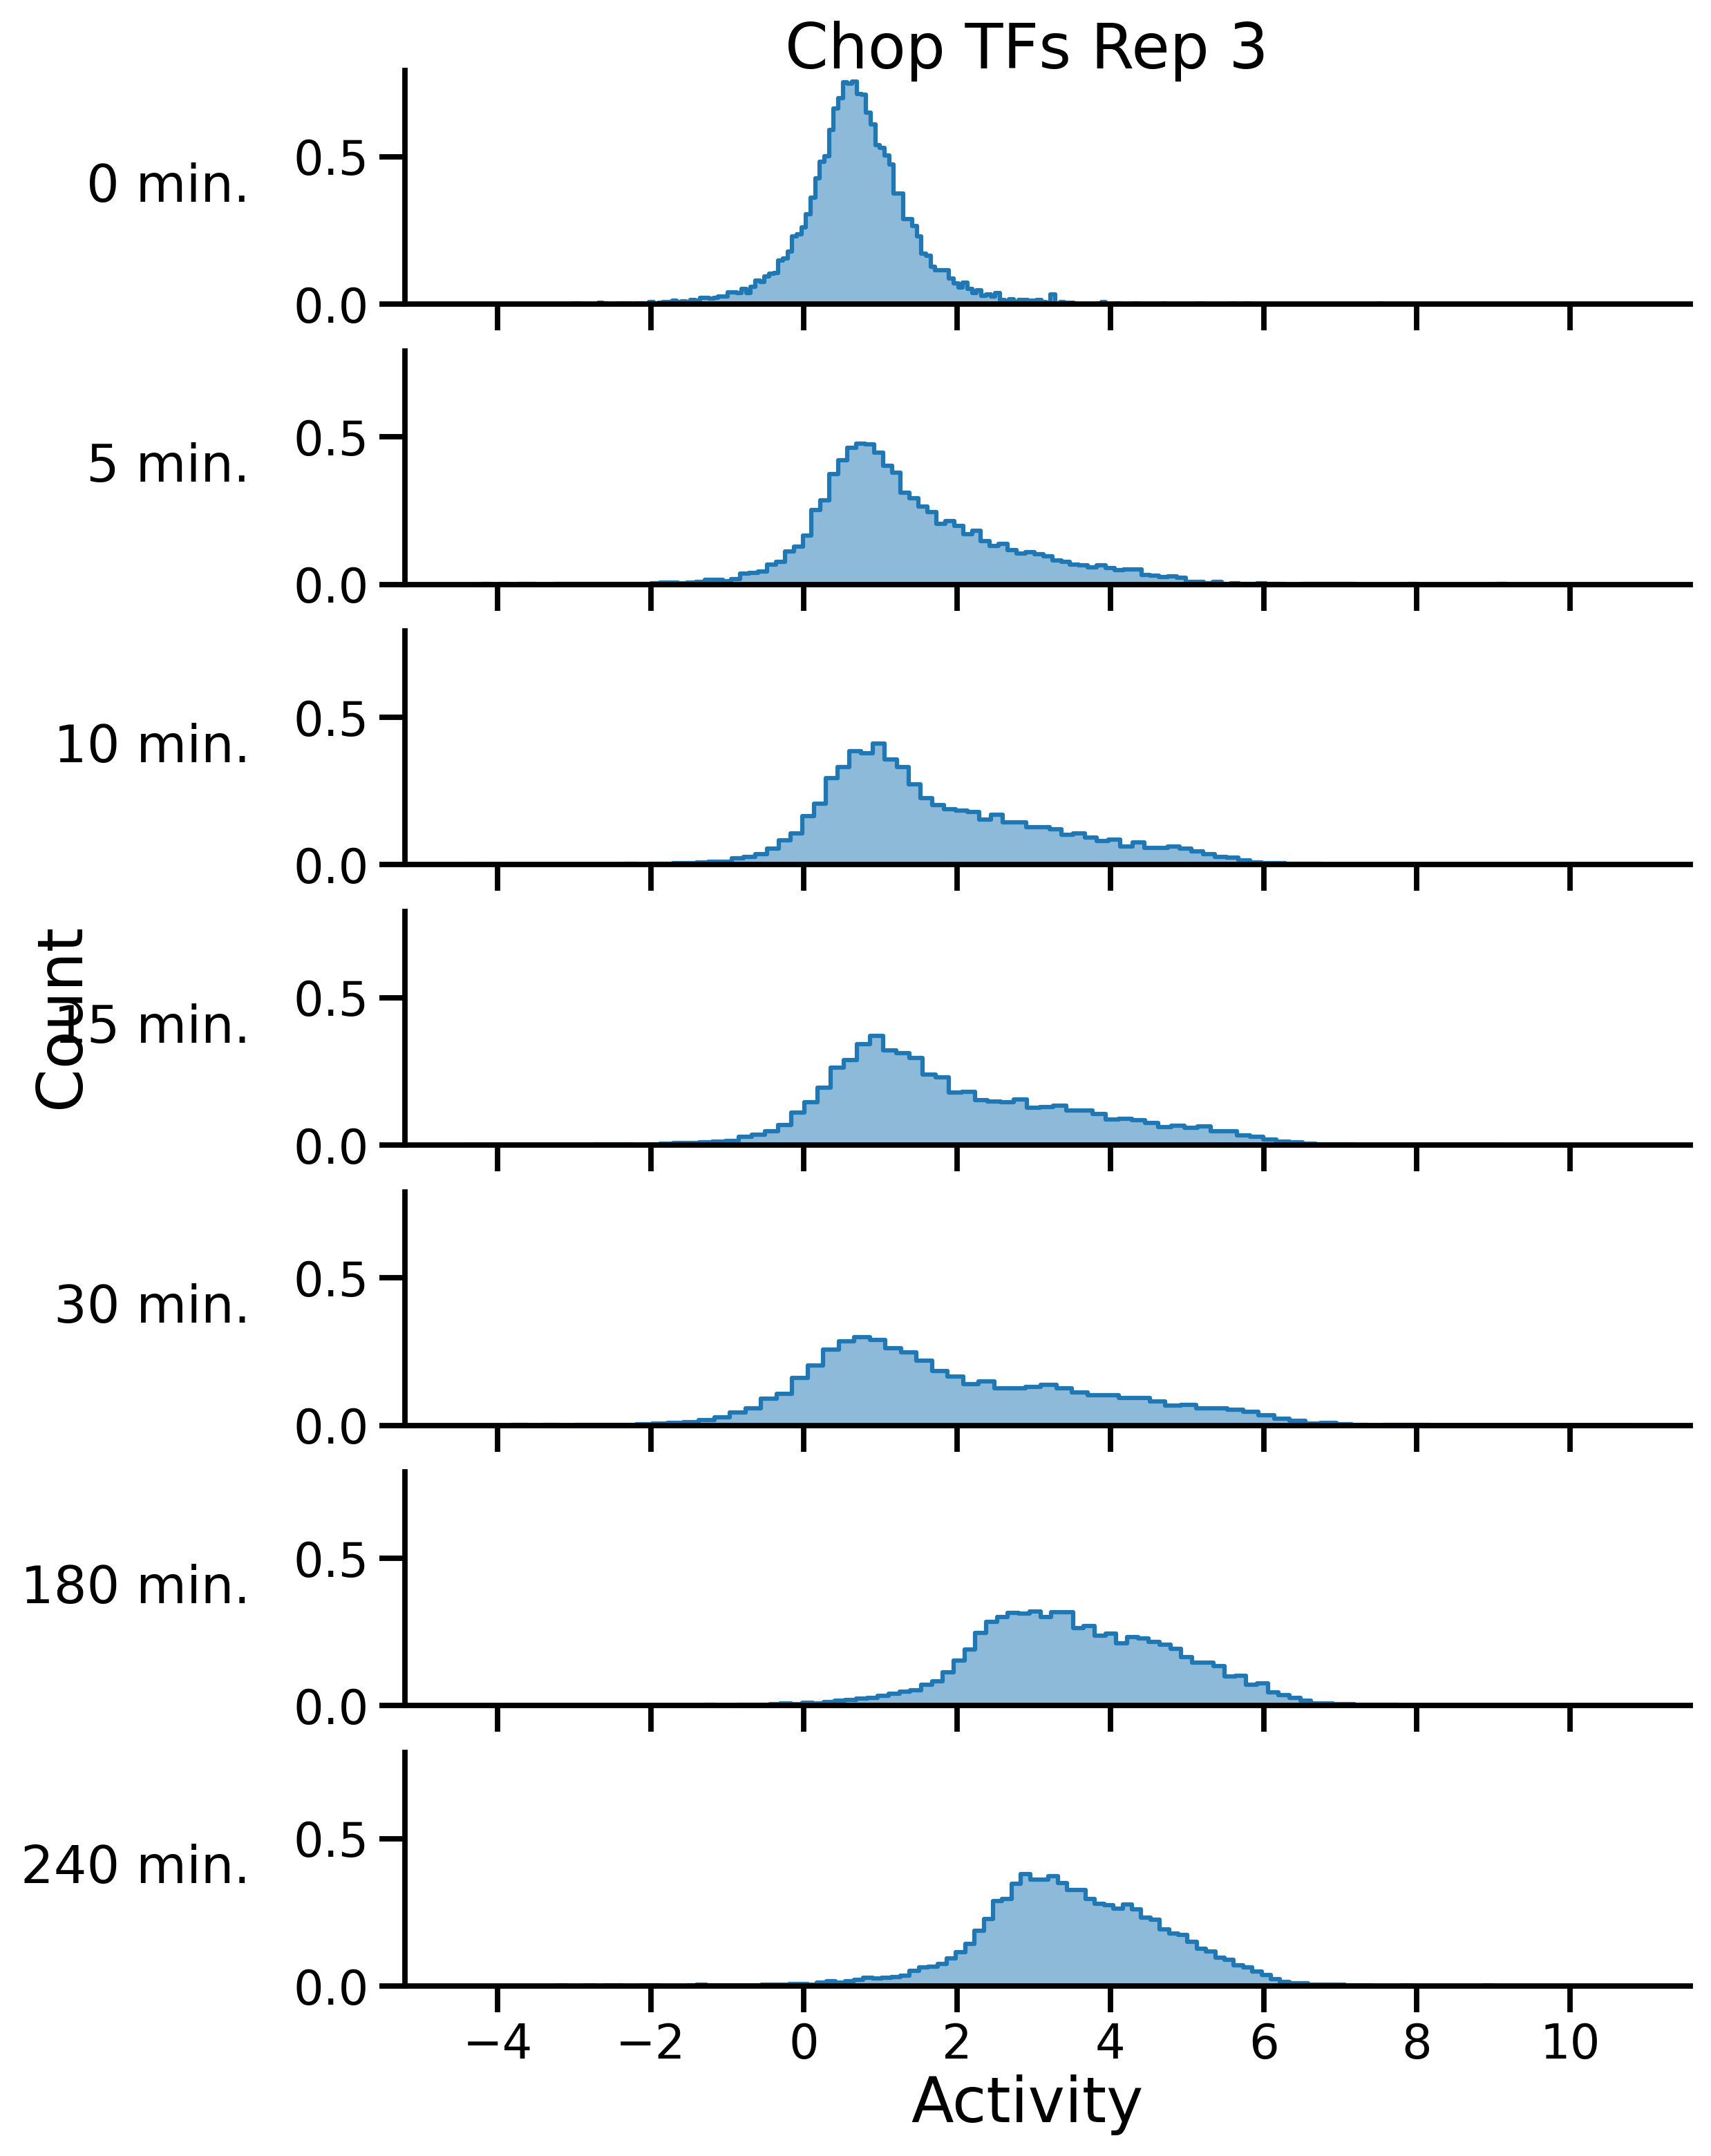

In [36]:
for rep in [1,2,3]:
    fig,axs = time_normalization_helpers.plot_hists_over_time(activities_per_bc[activities_per_bc["rep"] == rep], column = 'score_umi_pool_norm')

    # times = np.array(ad_df["time"].drop_duplicates().sort_values())
        
    # for i in tqdm(range(len(times))):
    #     sns.histplot(data = dbd_tiles[(dbd_tiles["rep"] == rep) & (dbd_tiles["time"] == times[i])], 
    #                  x = "activity_directional_mean", 
    #                  ax = axs[i],
    #                 stat = 'density', color = 'purple', binwidth = 0.05, label = "DBDs")
    #     axs[i].set_xlabel("")
    
    # axs[0].legend(ncols = 2)
    
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)

100%|██████████| 7/7 [00:00<00:00, 53.49it/s]


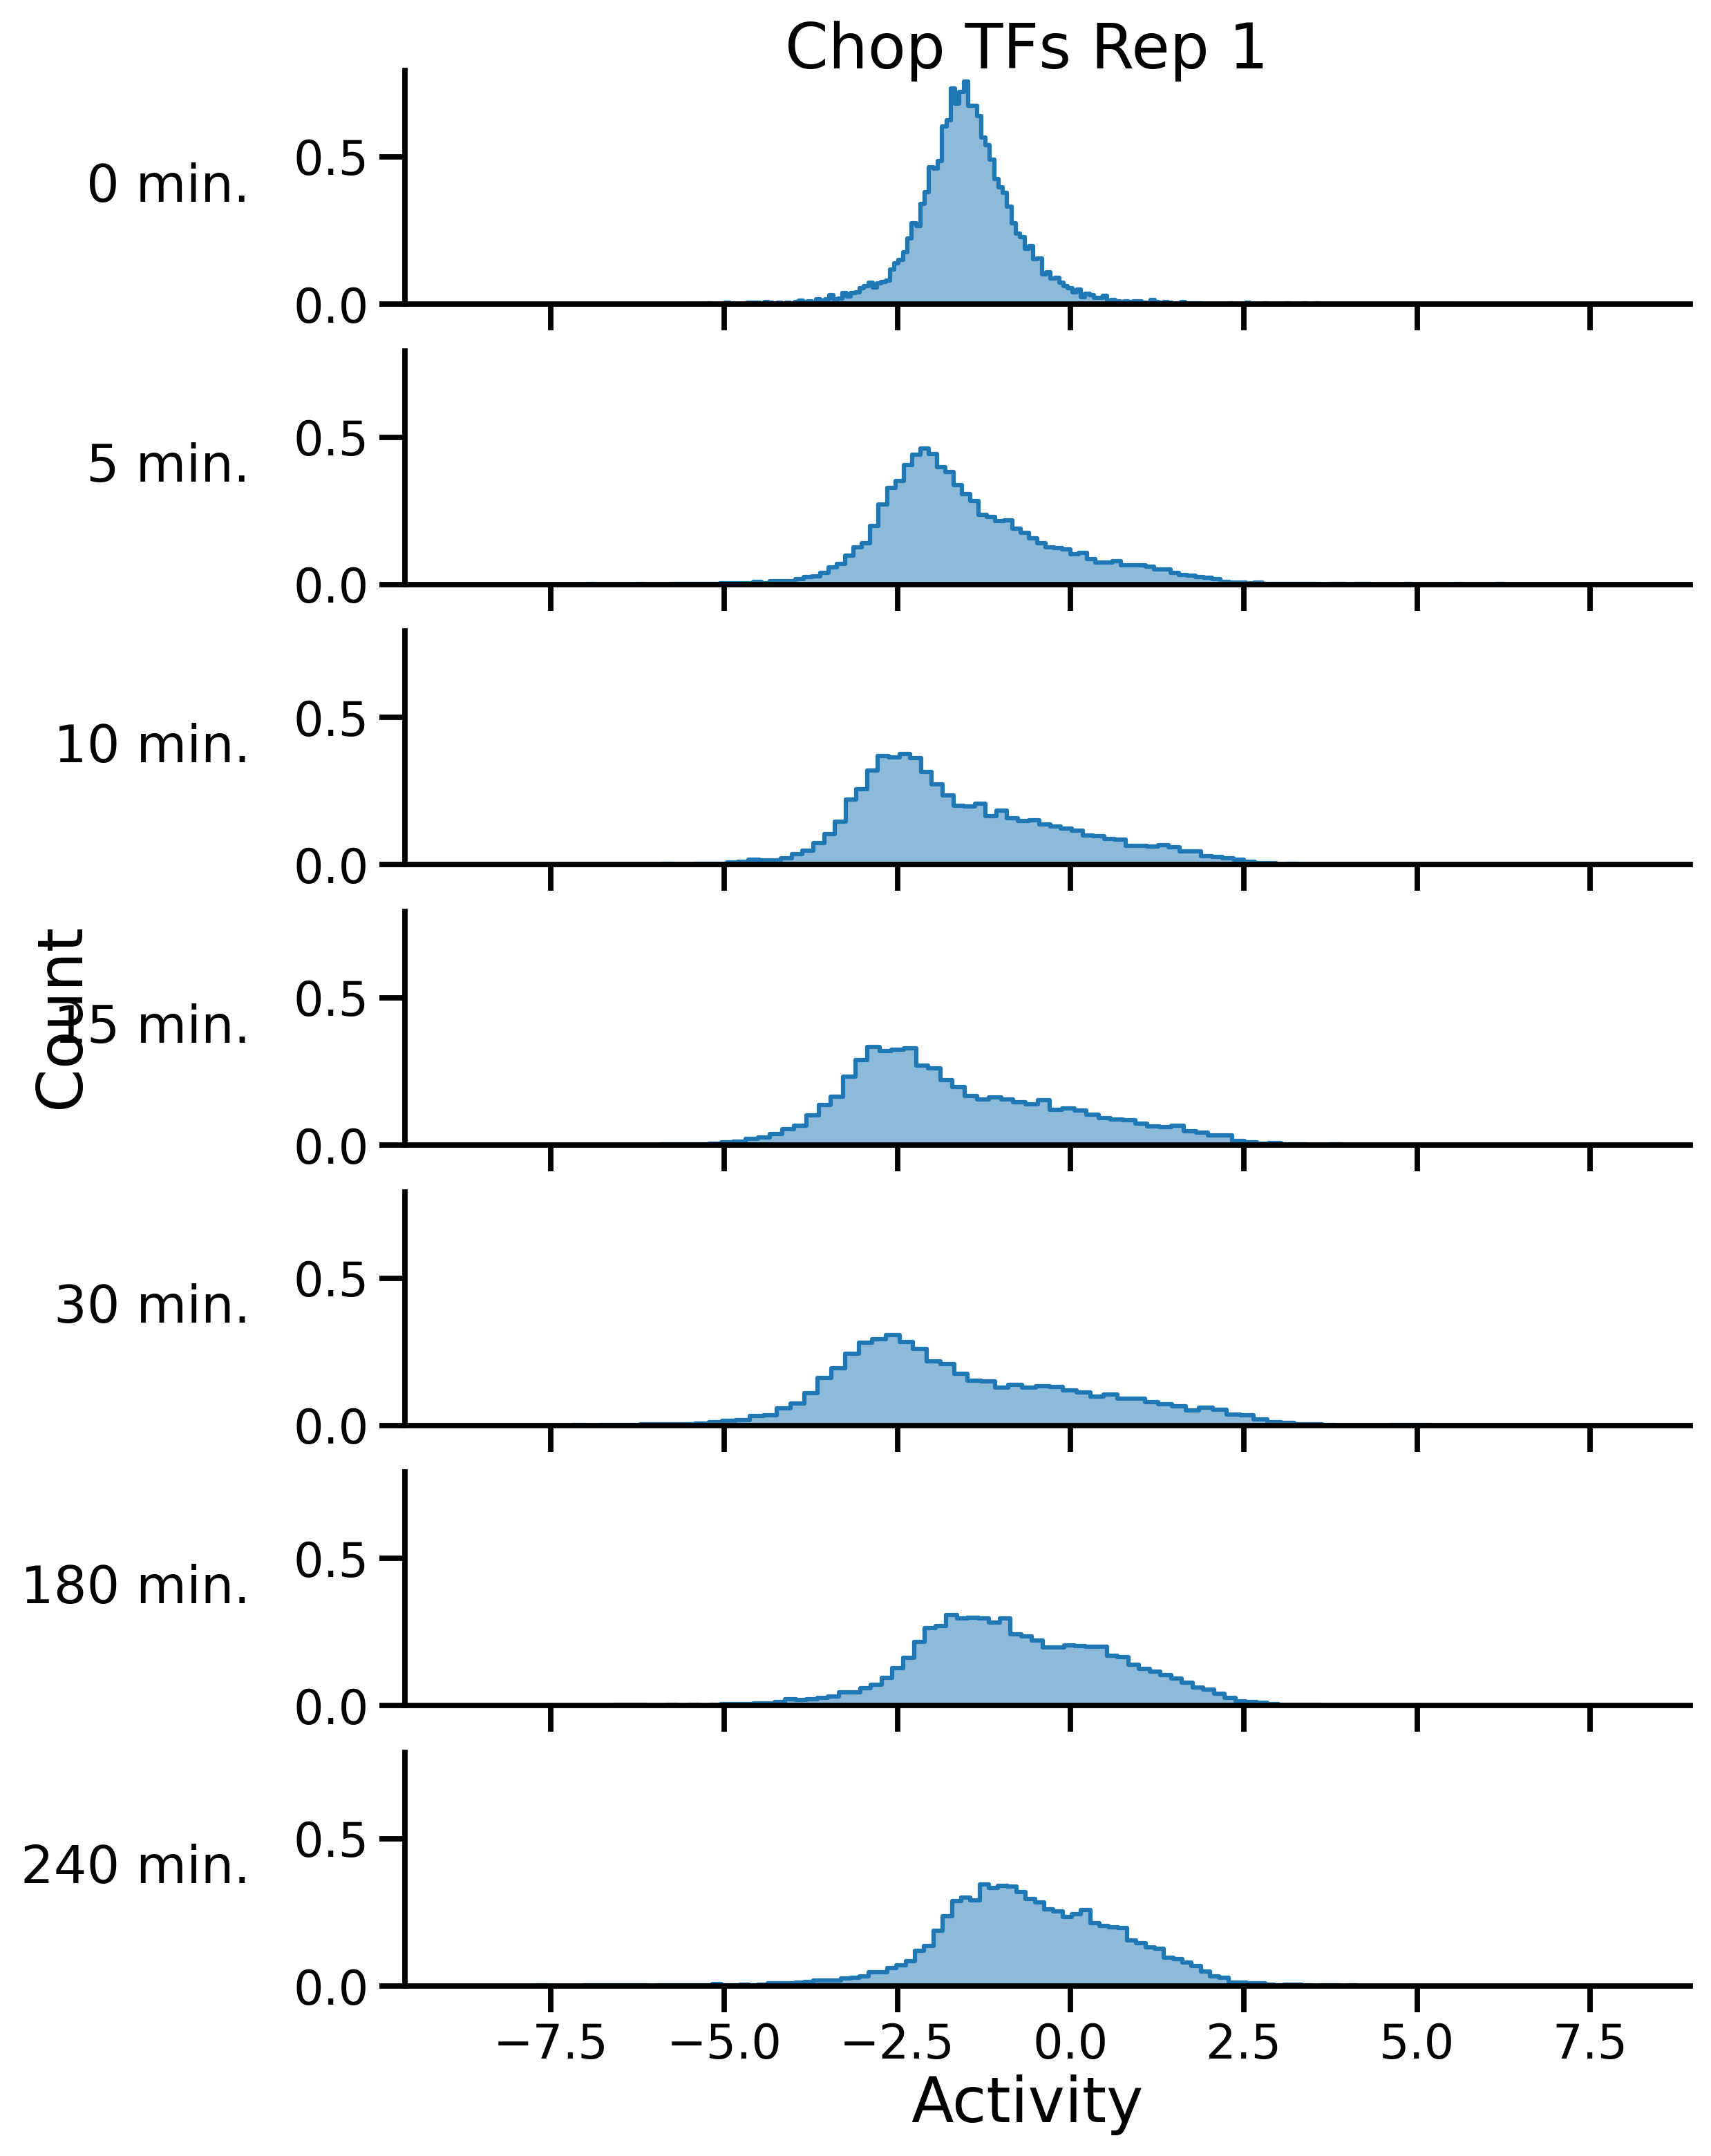

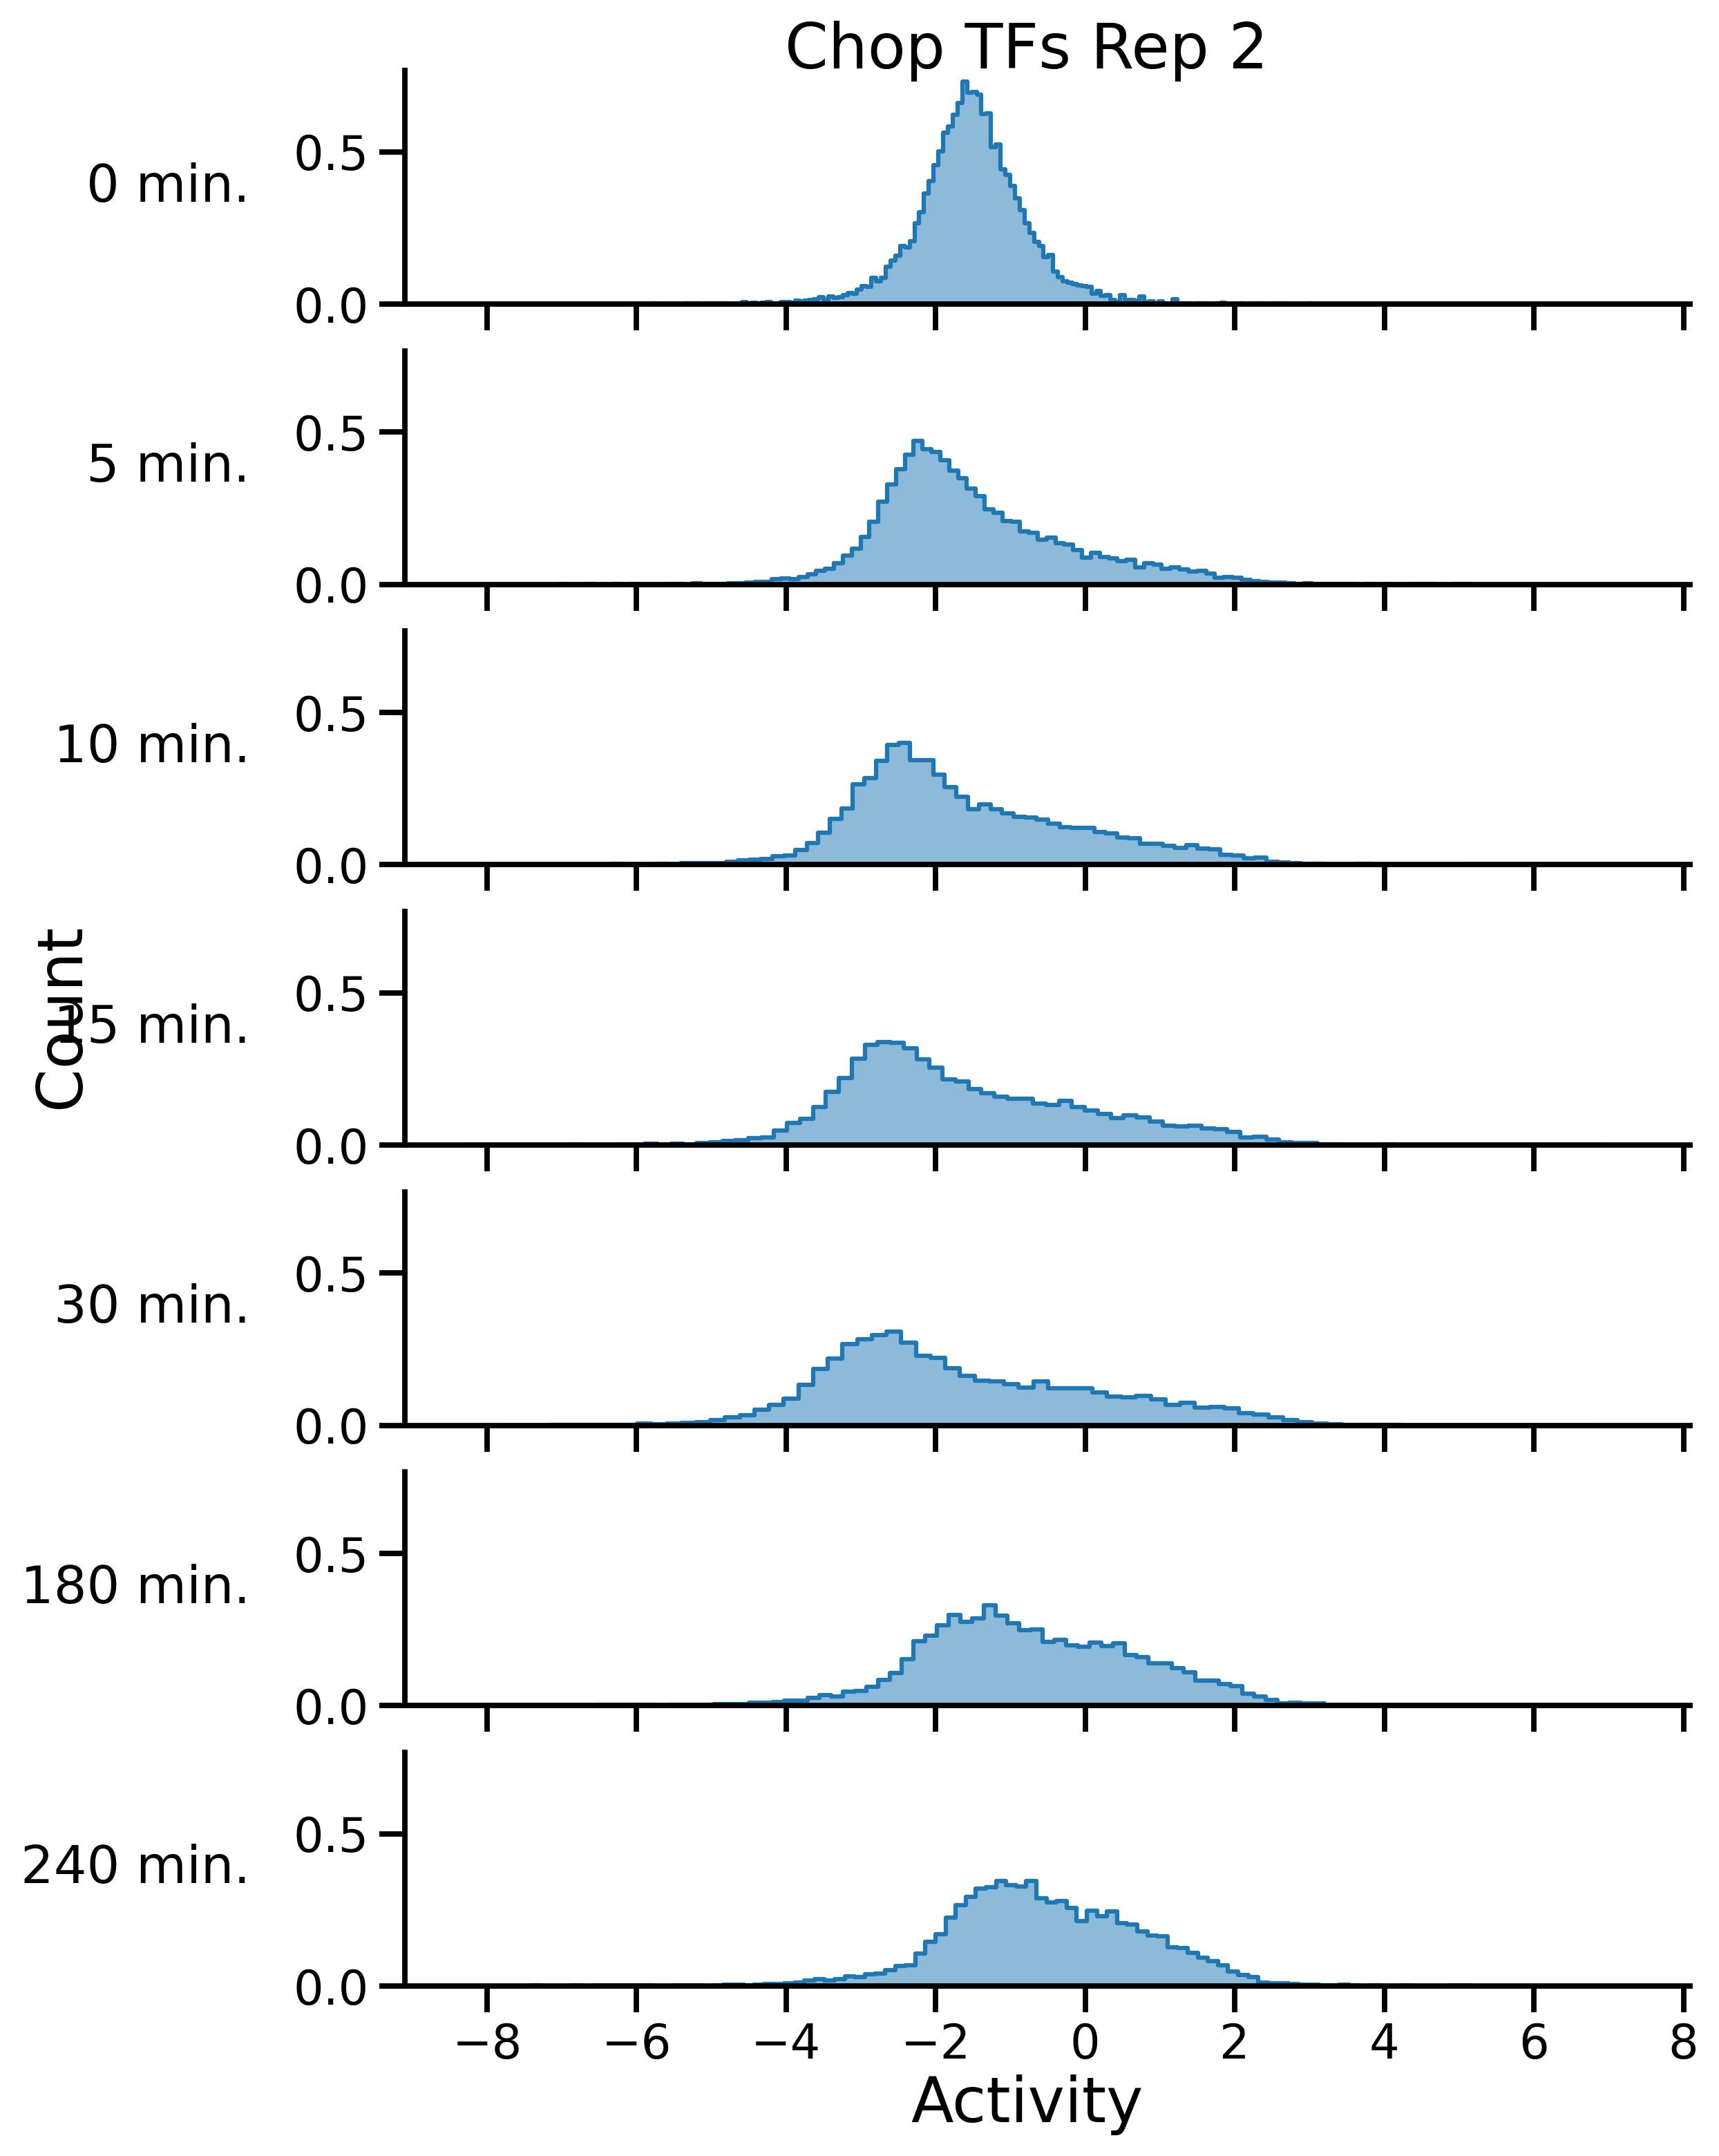

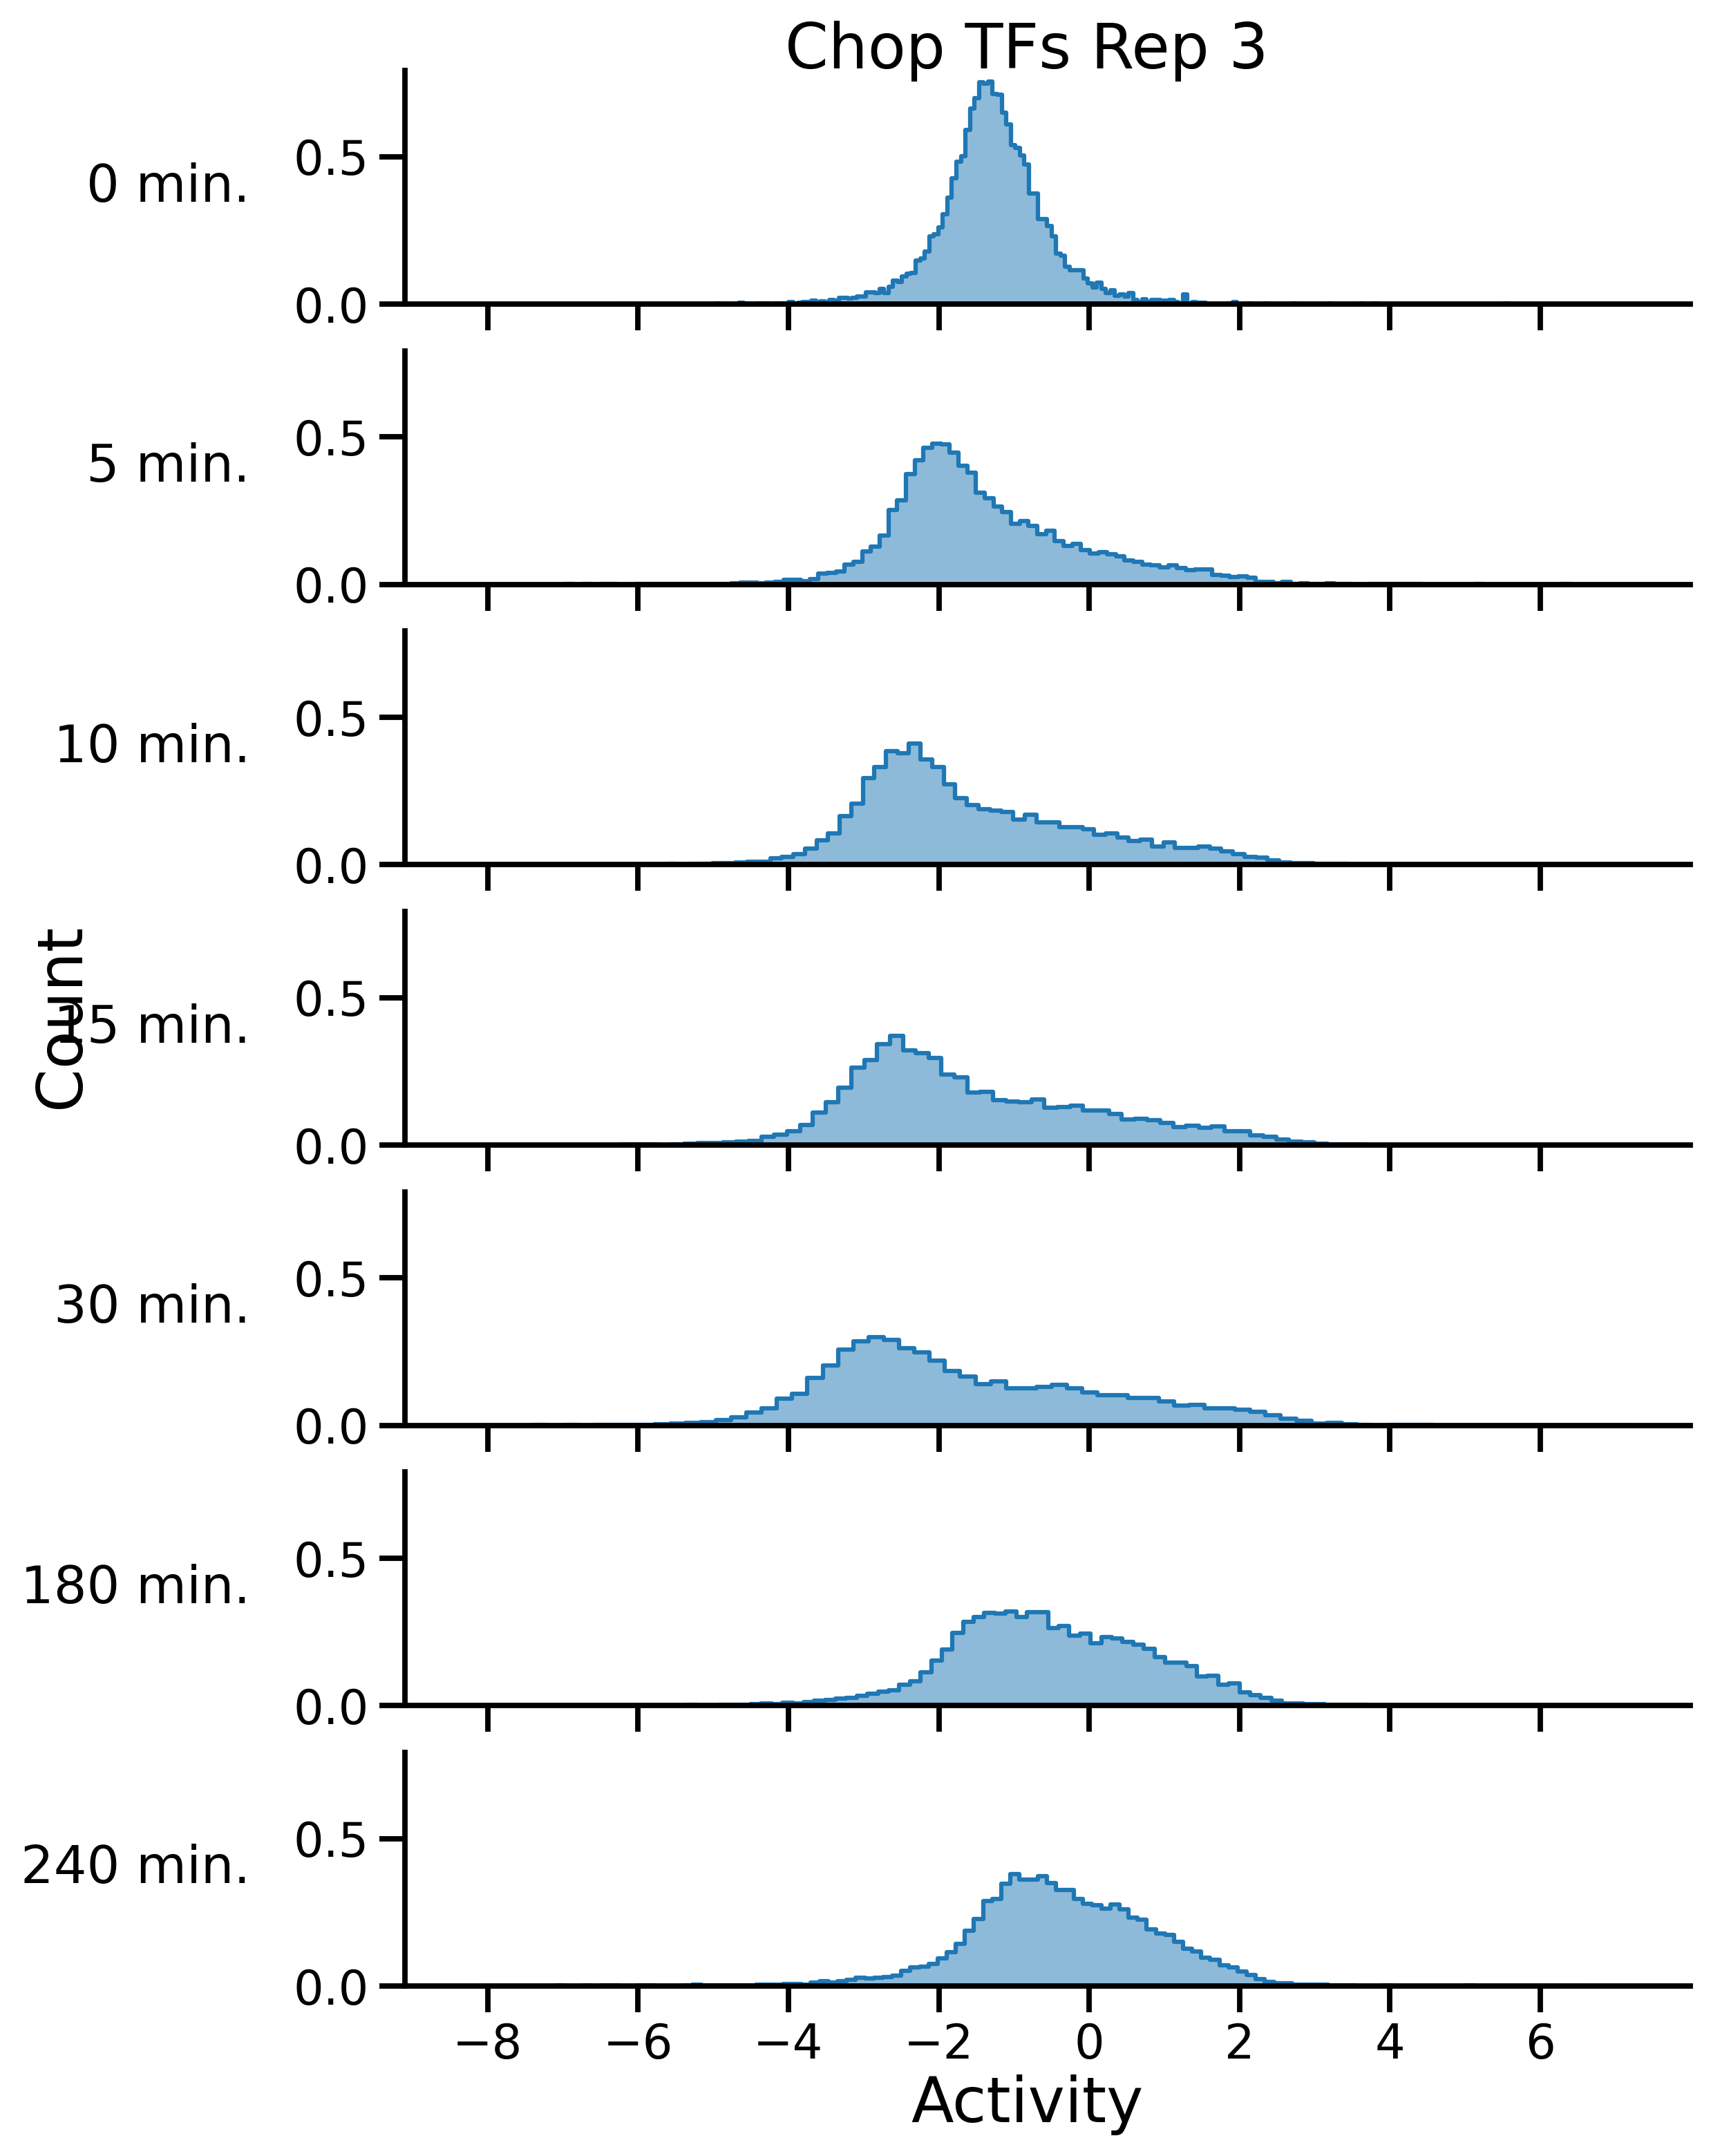

In [37]:
for rep in [1,2,3]:
    fig,axs = time_normalization_helpers.plot_hists_over_time(activities_per_bc[activities_per_bc["rep"] == rep], column = 'score_umi_only')

    # times = np.array(ad_df["time"].drop_duplicates().sort_values())
        
    # for i in tqdm(range(len(times))):
    #     sns.histplot(data = dbd_tiles[(dbd_tiles["rep"] == rep) & (dbd_tiles["time"] == times[i])], 
    #                  x = "activity_directional_mean", 
    #                  ax = axs[i],
    #                 stat = 'density', color = 'purple', binwidth = 0.05, label = "DBDs")
    #     axs[i].set_xlabel("")
    
    # axs[0].legend(ncols = 2)
    
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)